# Pokémon Card Price Prediction

### Predicting 30-Day Pokémon Card Prices Using Historical Market Data and Machine Learning

This project develops a machine learning pipeline to predict Pokémon card prices approximately 30 days into the future.

The analysis combines historical market prices with card metadata, performs entity matching and time-series feature engineering, and evaluates multiple machine learning models using an out of time test set.

The final model is evaluated against a naive baseline that assumes future prices remain the same to current prices.


In [1]:
import pandas as pd
import requests
import os
import json

## 1. Data Collection and Loading

In [2]:
!git clone https://github.com/PokemonTCG/pokemon-tcg-data.git

fatal: destination path 'pokemon-tcg-data' already exists and is not an empty directory.


In [3]:
os.listdir("pokemon-tcg-data")
os.listdir("pokemon-tcg-data/cards")[:20]
os.listdir("pokemon-tcg-data/cards/en")[:20]

['ex4.json',
 'sv10.json',
 'pop8.json',
 'bp.json',
 'swsh2.json',
 'me5.json',
 'sv3pt5.json',
 'ex3.json',
 'base6.json',
 'swsh7.json',
 'neo2.json',
 'dc1.json',
 'swsh1.json',
 'me2pt5.json',
 'swsh35.json',
 'xy3.json',
 'ex13.json',
 'mcd16.json',
 'sm35.json',
 'sv7.json']

In [4]:
file_path = 'pokemon-tcg-data/cards/en/sv6.json'

with open(file_path, "r") as file:
  cards = json.load(file)

print(type(cards))
print(len(cards))

<class 'list'>
226


In [5]:
cards[0]

{'id': 'sv6-1',
 'name': 'Tangela',
 'supertype': 'Pokémon',
 'subtypes': ['Basic'],
 'hp': '80',
 'types': ['Grass'],
 'evolvesTo': ['Tangrowth'],
 'attacks': [{'name': 'Gentle Slap',
   'cost': ['Colorless'],
   'convertedEnergyCost': 1,
   'damage': '10',
   'text': ''},
  {'name': 'Vine Slap',
   'cost': ['Grass', 'Colorless'],
   'convertedEnergyCost': 2,
   'damage': '30',
   'text': ''}],
 'weaknesses': [{'type': 'Fire', 'value': '×2'}],
 'retreatCost': ['Colorless', 'Colorless'],
 'convertedRetreatCost': 2,
 'number': '1',
 'artist': 'Yoriyuki Ikegami',
 'rarity': 'Common',
 'flavorText': "Hidden beneath a tangle of vines that grows nonstop even if the vines are torn off, this Pokémon's true appearance remains a mystery.",
 'nationalPokedexNumbers': [114],
 'legalities': {'unlimited': 'Legal',
  'standard': 'Legal',
  'expanded': 'Legal'},
 'regulationMark': 'H',
 'images': {'small': 'https://images.pokemontcg.io/sv6/1.png',
  'large': 'https://images.pokemontcg.io/sv6/1_hires.

In [6]:
df = pd.DataFrame(cards)
df.head()

,id,name,supertype,subtypes,hp,types,evolvesTo,attacks,weaknesses,retreatCost,...,rarity,flavorText,nationalPokedexNumbers,legalities,regulationMark,images,evolvesFrom,abilities,rules,resistances
0,sv6-1,Tangela,Pokémon,[Basic],80,[Grass],[Tangrowth],"[{'name': 'Gentle Slap', 'cost': ['Colorless']...","[{'type': 'Fire', 'value': '×2'}]","[Colorless, Colorless]",...,Common,Hidden beneath a tangle of vines that grows no...,[114],"{'unlimited': 'Legal', 'standard': 'Legal', 'e...",H,{'small': 'https://images.pokemontcg.io/sv6/1....,NaN,NaN,NaN,NaN
1,sv6-2,Tangrowth,Pokémon,[Stage 1],150,[Grass],NaN,"[{'name': 'Loom Over', 'cost': ['Grass', 'Colo...","[{'type': 'Fire', 'value': '×2'}]","[Colorless, Colorless, Colorless, Colorless]",...,Common,Tangrowth has two arms that it can extend as i...,[465],"{'unlimited': 'Legal', 'standard': 'Legal', 'e...",H,{'small': 'https://images.pokemontcg.io/sv6/2....,Tangela,"[{'name': 'Thicket Body', 'text': 'This Pokémo...",NaN,NaN
2,sv6-3,Pinsir,Pokémon,[Basic],110,[Grass],NaN,"[{'name': 'Slow Crunch', 'cost': ['Grass', 'Co...","[{'type': 'Fire', 'value': '×2'}]","[Colorless, Colorless]",...,Common,These Pokémon judge one another based on pince...,[127],"{'unlimited': 'Legal', 'standard': 'Legal', 'e...",H,{'small': 'https://images.pokemontcg.io/sv6/3....,NaN,NaN,NaN,NaN
3,sv6-4,Spinarak,Pokémon,[Basic],60,[Grass],[Ariados],"[{'name': 'Bug Bite', 'cost': ['Grass'], 'conv...","[{'type': 'Fire', 'value': '×2'}]",[Colorless],...,Common,Some fishers weave its sturdy thread into nets...,[167],"{'unlimited': 'Legal', 'standard': 'Legal', 'e...",H,{'small': 'https://images.pokemontcg.io/sv6/4....,NaN,NaN,NaN,NaN
4,sv6-5,Ariados,Pokémon,[Stage 1],90,[Grass],NaN,"[{'name': 'String Bind', 'cost': ['Grass'], 'c...","[{'type': 'Fire', 'value': '×2'}]",[Colorless],...,Uncommon,It wanders in search of food after darkness fa...,[168],"{'unlimited': 'Legal', 'standard': 'Legal', 'e...",H,{'small': 'https://images.pokemontcg.io/sv6/5....,Spinarak,"[{'name': 'Big Net', 'text': 'Your opponent's ...",NaN,NaN


In [7]:
print(df.shape)
print(df.columns.tolist())

(226, 23)
['id', 'name', 'supertype', 'subtypes', 'hp', 'types', 'evolvesTo', 'attacks', 'weaknesses', 'retreatCost', 'convertedRetreatCost', 'number', 'artist', 'rarity', 'flavorText', 'nationalPokedexNumbers', 'legalities', 'regulationMark', 'images', 'evolvesFrom', 'abilities', 'rules', 'resistances']


In [8]:
cards_folder = 'pokemon-tcg-data/cards/en'
json_files = [file for file in os.listdir(cards_folder) if file.endswith('.json')]

print("Number of sets:", len(json_files))
print(json_files[:10])

Number of sets: 174
['ex4.json', 'sv10.json', 'pop8.json', 'bp.json', 'swsh2.json', 'me5.json', 'sv3pt5.json', 'ex3.json', 'base6.json', 'swsh7.json']


In [9]:
all_cards = []

for file in json_files:
  file_path = os.path.join(cards_folder, file)
  with open(file_path, "r") as f:
    cards = json.load(f)
    all_cards.extend(cards)

print("Total number of cards:", len(all_cards))

Total number of cards: 20444


In [10]:
all_cards_df = pd.DataFrame(all_cards)

print(all_cards_df.shape)
all_cards_df.head()

(20444, 25)


,id,name,supertype,subtypes,hp,types,evolvesFrom,rules,attacks,weaknesses,...,nationalPokedexNumbers,legalities,images,abilities,resistances,evolvesTo,regulationMark,level,flavorText,ancientTrait
0,ex4-1,Team Aqua's Cacturne,Pokémon,[Stage 1],80,"[Grass, Darkness]",Team Aqua's Cacnea,[This Pokémon is both Grass Darkness type.],"[{'name': 'Dark Bind', 'cost': ['Darkness'], '...","[{'type': 'Fire', 'value': '×2'}]",...,[332],{'unlimited': 'Legal'},{'small': 'https://images.pokemontcg.io/ex4/1....,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ex4-2,Team Aqua's Crawdaunt,Pokémon,[Stage 1],80,"[Water, Darkness]",Team Aqua's Corphish,[This Pokémon is both Water Darkness type.],"[{'name': 'Aqua Reverse', 'cost': ['Darkness',...","[{'type': 'Lightning', 'value': '×2'}]",...,[342],{'unlimited': 'Legal'},{'small': 'https://images.pokemontcg.io/ex4/2....,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ex4-3,Team Aqua's Kyogre,Pokémon,[Basic],100,"[Water, Darkness]",NaN,[This Pokémon is both Water Darkness type.],"[{'name': 'Aqua Trip', 'cost': ['Water', 'Colo...","[{'type': 'Grass', 'value': '×2'}]",...,[382],{'unlimited': 'Legal'},{'small': 'https://images.pokemontcg.io/ex4/3....,"[{'name': 'Power Saver', 'text': 'As long as t...",NaN,NaN,NaN,NaN,NaN,NaN
3,ex4-4,Team Aqua's Manectric,Pokémon,[Stage 1],70,"[Lightning, Darkness]",Team Aqua's Electrike,[This Pokémon is both Lightning Darkness type.],"[{'name': 'Thunderspark', 'cost': ['Lightning'...","[{'type': 'Fighting', 'value': '×2'}]",...,[310],{'unlimited': 'Legal'},{'small': 'https://images.pokemontcg.io/ex4/4....,"[{'name': 'Power Shift', 'text': 'Once during ...","[{'type': 'Metal', 'value': '-30'}]",NaN,NaN,NaN,NaN,NaN
4,ex4-5,Team Aqua's Sharpedo,Pokémon,[Stage 1],70,"[Water, Darkness]",Team Aqua's Carvanha,[This Pokémon is both Water Darkness type.],"[{'name': 'Rage', 'cost': ['Colorless', 'Color...","[{'type': 'Lightning', 'value': '×2'}]",...,[319],{'unlimited': 'Legal'},{'small': 'https://images.pokemontcg.io/ex4/5....,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(all_cards_df.shape)

(20444, 25)


In [12]:
all_cards_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20444 entries, 0 to 20443
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      20444 non-null  object 
 1   name                    20444 non-null  object 
 2   supertype               20444 non-null  object 
 3   subtypes                20270 non-null  object 
 4   hp                      17290 non-null  object 
 5   types                   17249 non-null  object 
 6   evolvesFrom             7373 non-null   object 
 7   rules                   6300 non-null   object 
 8   attacks                 17262 non-null  object 
 9   weaknesses              16744 non-null  object 
 10  retreatCost             16330 non-null  object 
 11  convertedRetreatCost    16331 non-null  float64
 12  number                  20444 non-null  object 
 13  artist                  18833 non-null  object 
 14  rarity                  20149 non-null

In [13]:
all_cards_df.isnull().sum().sort_values(ascending = False)

,0
ancientTrait,20385
level,18040
abilities,16368
resistances,15570
rules,14144
evolvesTo,13936
evolvesFrom,13071
regulationMark,12250
flavorText,9510
retreatCost,4114


In [14]:
all_cards_df.columns.tolist()

['id',
 'name',
 'supertype',
 'subtypes',
 'hp',
 'types',
 'evolvesFrom',
 'rules',
 'attacks',
 'weaknesses',
 'retreatCost',
 'convertedRetreatCost',
 'number',
 'artist',
 'rarity',
 'nationalPokedexNumbers',
 'legalities',
 'images',
 'abilities',
 'resistances',
 'evolvesTo',
 'regulationMark',
 'level',
 'flavorText',
 'ancientTrait']

In [15]:
all_cards_df["rarity"].value_counts()

,count
rarity,
Common,5334
Uncommon,4888
Rare,2562
Rare Holo,1617
Promo,1220
Rare Ultra,798
Illustration Rare,492
Ultra Rare,356
Rare Secret,325


In [16]:
!wget -q https://github.com/tcgdex/price-history/archive/refs/heads/master.zip -O price_history.zip

In [17]:
!unzip -oq price_history.zip

In [18]:
os.listdir('price-history-master')[:20]

['README.md', 'en', 'fr', 'meta']

In [19]:
os.listdir("price-history-master/en")[:20]

['dp3',
 'ru1',
 'sm115',
 'xy10',
 'np',
 'sv03.5',
 'sm8',
 'ex5',
 'neo4',
 'lc',
 'sm7',
 'swsh3.5',
 'base1',
 'ex7',
 'sv02',
 'bw6',
 'dv1',
 'bw11',
 'gym2',
 'swsh5']

In [20]:
for root, dirs, files in os.walk('price-history-master/en'):
  print("Folder:", root)
  print("Files:", files[:5])
  print("Subfolders:", dirs[:5])
  break

Folder: price-history-master/en
Files: []
Subfolders: ['dp3', 'ru1', 'sm115', 'xy10', 'np']


In [21]:
os.listdir("price-history-master/en/swsh10")[:20]

['154.tcgplayer.json',
 '102.tcgplayer.json',
 '188.tcgplayer.json',
 '215.tcgplayer.json',
 '172.tcgplayer.json',
 '135.tcgplayer.json',
 '139.tcgplayer.json',
 '173.tcgplayer.json',
 '196.tcgplayer.json',
 '118.tcgplayer.json',
 '161.tcgplayer.json',
 '117.tcgplayer.json',
 '100.tcgplayer.json',
 '177.tcgplayer.json',
 '205.tcgplayer.json',
 '170.tcgplayer.json',
 '132.tcgplayer.json',
 '104.tcgplayer.json',
 '212.tcgplayer.json',
 '101.tcgplayer.json']

In [22]:
sample_folder = 'price-history-master/en/swsh10'
for file in os.listdir(sample_folder)[:5]:
  print(file)

154.tcgplayer.json
102.tcgplayer.json
188.tcgplayer.json
215.tcgplayer.json
172.tcgplayer.json


In [23]:
sample_file = os.path.join(sample_folder, os.listdir(sample_folder)[0])
with open(sample_file, 'r') as f:
  sample_price = json.load(f)
sample_price

{'data': {'reverse-good': {'history': {'2022-12-06': {'avg': 143,
     'count': 6,
     'min': 124,
     'max': 147},
    '2022-12-07': {'avg': 899, 'count': 4, 'min': 899, 'max': 899},
    '2022-12-09': {'avg': 167, 'count': 1, 'min': 167, 'max': 167},
    '2022-12-11': {'avg': 107, 'count': 7, 'min': 90, 'max': 150},
    '2022-12-12': {'avg': 156, 'count': 12, 'min': 99, 'max': 198},
    '2022-12-13': {'avg': 85, 'count': 4, 'min': 74, 'max': 88},
    '2022-12-14': {'avg': 143, 'count': 20, 'min': 73, 'max': 196},
    '2022-12-15': {'avg': 174, 'count': 7, 'min': 174, 'max': 174},
    '2022-12-16': {'avg': 140, 'count': 12, 'min': 74, 'max': 189},
    '2022-12-17': {'avg': 124, 'count': 12, 'min': 88, 'max': 187},
    '2022-12-18': {'avg': 115, 'count': 6, 'min': 88, 'max': 169},
    '2022-12-20': {'avg': 432, 'count': 13, 'min': 215, 'max': 450},
    '2022-12-22': {'avg': 106, 'count': 6, 'min': 63, 'max': 149},
    '2022-12-23': {'avg': 167, 'count': 4, 'min': 159, 'max': 174},
   

In [24]:
print("File name:", os.path.basename(sample_file))
print("Full path:", sample_file)

File name: 154.tcgplayer.json
Full path: price-history-master/en/swsh10/154.tcgplayer.json


In [25]:
print(sample_price.keys())
print(sample_price['data'].keys())

dict_keys(['data'])
dict_keys(['reverse-good', 'normal-good', 'normal-nearmint', 'reverse-nearmint', 'reverse-played', 'reverse-used', 'normal-played', 'normal-poor', 'normal-used', 'reverse-poor'])


## 2. Data Cleaning and Entity Matching

In [26]:
match = all_cards_df[
    (all_cards_df['id'].str.startswith('swsh10-')) &
    (all_cards_df['number'] == "100")
]

match[['id', 'name', 'number', 'rarity', 'artist']]

,id,name,number,rarity,artist
16273,swsh10-100,Hisuian Samurott,100,Rare Holo,Kouki Saitou


In [27]:
price_rows = []

for condition, condition_data in sample_price['data'].items():
  history = condition_data.get("history", {})

  for date, values in history.items():
    price_rows.append({
        'set_id': 'swsh10',
        'card_number': '100',
        'condition': condition,
        'date': date,
        'avg_price': values.get('avg'),
        'min_price': values.get('min'),
        'max_price': values.get('max'),
        'count': values.get('count')
    })
sample_price_df = pd.DataFrame(price_rows)
sample_price_df.head()

,set_id,card_number,condition,date,avg_price,min_price,max_price,count
0,swsh10,100,reverse-good,2022-12-06,143,124,147,6
1,swsh10,100,reverse-good,2022-12-07,899,899,899,4
2,swsh10,100,reverse-good,2022-12-09,167,167,167,1
3,swsh10,100,reverse-good,2022-12-11,107,90,150,7
4,swsh10,100,reverse-good,2022-12-12,156,99,198,12


In [28]:
print(sample_price_df.shape)
sample_price_df.head(10)

(879, 8)


,set_id,card_number,condition,date,avg_price,min_price,max_price,count
0,swsh10,100,reverse-good,2022-12-06,143,124,147,6
1,swsh10,100,reverse-good,2022-12-07,899,899,899,4
2,swsh10,100,reverse-good,2022-12-09,167,167,167,1
3,swsh10,100,reverse-good,2022-12-11,107,90,150,7
4,swsh10,100,reverse-good,2022-12-12,156,99,198,12
5,swsh10,100,reverse-good,2022-12-13,85,74,88,4
6,swsh10,100,reverse-good,2022-12-14,143,73,196,20
7,swsh10,100,reverse-good,2022-12-15,174,174,174,7
8,swsh10,100,reverse-good,2022-12-16,140,74,189,12
9,swsh10,100,reverse-good,2022-12-17,124,88,187,12


In [29]:
price_root = 'price-history-master/en'
total_files = 0

for root, dirs, files in os.walk(price_root):
  total_files += len([f for f in files if f.endswith(".json")])

print("Total price files:", total_files)

Total price files: 14958


In [30]:
set_folders = [
    folder for folder in os.listdir(price_root)
    if os.path.isdir(os.path.join(price_root, folder))
]

print("Number of sets:", len(set_folders))
print(set_folders[:10])

Number of sets: 137
['dp3', 'ru1', 'sm115', 'xy10', 'np', 'sv03.5', 'sm8', 'ex5', 'neo4', 'lc']


In [31]:
price_rows = []
for set_id in set_folders:
  set_path = os.path.join(price_root, set_id)

  for file in os.listdir(set_path):
    if not file.endswith(".json"):
      continue

    file_path = os.path.join(set_path, file)
    with open(file_path, 'r') as f:
      price_data = json.load(f)

    card_number = file.split(".")[0]

    for condition, condition_data in price_data['data'].items():
      history = condition_data.get("history", {})

      for date, values in history.items():
        price_rows.append({
            'set_id': set_id,
            'card_number': card_number,
            'condition': condition,
            'date': date,
            'avg_price': values.get('avg'),
            'min_price': values.get('min'),
            'max_price': values.get('max'),
            'count': values.get('count')
        })

all_prices_df = pd.DataFrame(price_rows)

print(all_prices_df.shape)
all_prices_df.head()

(2219077, 8)


,set_id,card_number,condition,date,avg_price,min_price,max_price,count
0,dp3,102,normal-good,2022-12-11,75,75.0,75.0,1
1,dp3,102,normal-good,2022-12-16,75,75.0,75.0,1
2,dp3,102,normal-good,2022-12-29,32,23.0,40.0,2
3,dp3,102,normal-good,2023-01-02,24,23.0,25.0,2
4,dp3,102,normal-good,2023-01-05,10,10.0,10.0,1


In [32]:
all_prices_df['date'] = pd.to_datetime(all_prices_df['date'])

print(all_prices_df.shape)
print(all_prices_df['date'].min())
print(all_prices_df['date'].max())
print(all_prices_df['set_id'].nunique())
print(all_prices_df['card_number'].nunique())

(2219077, 8)
2022-11-12 00:00:00
2024-09-24 00:00:00
137
1090


In [33]:
unique_cards = all_prices_df[
    ['set_id', 'card_number']
].drop_duplicates()

print("Unique cards with price data:", len(unique_cards))

Unique cards with price data: 14958


In [34]:
all_cards_df['set_id'] = all_cards_df['id'].str.rsplit("-", n=1).str[0]
all_cards_df[['id', 'set_id', 'number', 'name']].head()

,id,set_id,number,name
0,ex4-1,ex4,1,Team Aqua's Cacturne
1,ex4-2,ex4,2,Team Aqua's Crawdaunt
2,ex4-3,ex4,3,Team Aqua's Kyogre
3,ex4-4,ex4,4,Team Aqua's Manectric
4,ex4-5,ex4,5,Team Aqua's Sharpedo


In [35]:
metadata_df = all_cards_df.rename(
    columns = {'number': 'card_number'}
)

In [36]:
match_test = unique_cards.merge(
    metadata_df,
    on = ['set_id', 'card_number'],
    how = 'left',
    indicator = True
)

match_test["_merge"].value_counts()

,count
_merge,
both,13574
left_only,1384
right_only,0


In [37]:
matched = (match_test['_merge'] == 'both').sum()
total = len(match_test)
match_rate = matched / total * 100

print("Total price cards:", total)
print("Matched cards:", matched)
print("Unmatched cards:", total - matched)
print(f"Match rate: {match_rate:.2f}%")

Total price cards: 14958
Matched cards: 13574
Unmatched cards: 1384
Match rate: 90.75%


In [38]:
unmatched = match_test[
    match_test['_merge'] == 'left_only'
]

unmatched[['set_id', 'card_number']].head(20)

,set_id,card_number
378,sv03.5,154
379,sv03.5,102
380,sv03.5,188
381,sv03.5,172
382,sv03.5,135
383,sv03.5,139
384,sv03.5,173
385,sv03.5,196
386,sv03.5,118
387,sv03.5,161


In [39]:
unmatched['set_id'].value_counts().head(20)

,count
set_id,
sv02,180
sv04,167
sv01,159
sv03,131
lc,110
sv03.5,108
swsh3.5,80
sm3.5,78
sm7.5,78


In [40]:
price_sv_sets = sorted([
    x for x in unique_cards['set_id'].unique()
    if x.startswith('sv')
])

metadata_sv_sets = sorted([
    x for x in metadata_df['set_id'].unique()
    if x.startswith('sv')
])

print('PRICE DATA:')
print(price_sv_sets)

print("\nMETADATA:")
print(metadata_sv_sets)

PRICE DATA:
['sv01', 'sv02', 'sv03', 'sv03.5', 'sv04']

METADATA:
['sv1', 'sv10', 'sv2', 'sv3', 'sv3pt5', 'sv4', 'sv4pt5', 'sv5', 'sv6', 'sv6pt5', 'sv7', 'sv8', 'sv8pt5', 'sv9', 'sve', 'svp']


In [41]:
print("PRICE .5 SETS:")
print(sorted([
    x for x in unique_cards['set_id'].unique()
    if '.5' in x
]))

print("\nMETADATA .5 SETS:")
print(sorted([
    x for x in metadata_df['set_id'].unique()
    if '.5' in x
]))

PRICE .5 SETS:
['sm3.5', 'sm7.5', 'sv03.5', 'swsh12.5', 'swsh3.5', 'swsh4.5']

METADATA .5 SETS:
[]


In [42]:
set_id_mapping = {
    'sv01': 'sv1',
    'sv02': 'sv2',
    'sv03': 'sv3',
    'sv04': 'sv4',
    'sv03.5': 'sv3pt5'
}

unique_cards_fixed = unique_cards.copy()
unique_cards_fixed['set_id'] = (
    unique_cards_fixed['set_id'].replace(set_id_mapping)
)

In [43]:
match_test_fixed = unique_cards_fixed.merge(
    metadata_df,
    on = ['set_id', 'card_number'],
    how = 'left',
    indicator = True
)

matched_fixed = (match_test_fixed['_merge'] == 'both').sum()
total = len(match_test_fixed)

print("Total price cards:", total)
print("Matched cards:", matched_fixed)
print("Unmatched cards:", total - matched_fixed)
print(f"Match rate: {matched_fixed / total * 100:.2f}%")

Total price cards: 14958
Matched cards: 14319
Unmatched cards: 639
Match rate: 95.73%


In [44]:
unmatched_fixed = match_test_fixed[
    match_test_fixed["_merge"] == "left_only"
]
print("remaining unmatched:", len(unmatched_fixed))
unmatched_fixed['set_id'].value_counts().head(30)

remaining unmatched: 639


,count
set_id,
lc,110
swsh3.5,80
sm7.5,78
sm3.5,78
swsh4.5,73
swsh12.5,61
2021swsh,25
hgssp,24
2011bw,12


In [45]:
metadata_sets = sorted(metadata_df['set_id'].unique())

for x in metadata_sets:
  if(
      x.startswith('swsh') or
      x.startswith('sm') or
      x == 'lc' or
      'hgss' in x
  ):
      print(x)

hgss1
hgss2
hgss3
hgss4
sm1
sm10
sm11
sm115
sm12
sm2
sm3
sm35
sm4
sm5
sm6
sm7
sm75
sm8
sm9
sma
smp
swsh1
swsh10
swsh10tg
swsh11
swsh11tg
swsh12
swsh12pt5
swsh12pt5gg
swsh12tg
swsh2
swsh3
swsh35
swsh4
swsh45
swsh45sv
swsh5
swsh6
swsh7
swsh8
swsh9
swsh9tg
swshp


In [46]:
set_id_mapping.update({
    'sm3.5': 'sm35',
    'sm7.5': 'sm75',
    'swsh3.5': 'swsh35',
    'swsh4.5': 'swsh45',
    'swsh12.5': 'swsh12pt5'
})

In [47]:
unique_cards_fixed = unique_cards.copy()

unique_cards_fixed['set_id'] = (
    unique_cards_fixed['set_id'].replace(set_id_mapping)
)

In [48]:
match_test_fixed = unique_cards_fixed.merge(
    metadata_df,
    on = ['set_id', 'card_number'],
    how = 'left',
    indicator = True
)

matched_fixed = (match_test_fixed['_merge'] == 'both').sum()
total = len(match_test_fixed)

print("Total price cards:", total)
print("Matched cards:", matched_fixed)
print("Unmatched cards:", total - matched_fixed)
print(f"Match rate: {matched_fixed / total * 100:.2f}%")

Total price cards: 14958
Matched cards: 14689
Unmatched cards: 269
Match rate: 98.20%


In [49]:
unmatched_fixed = match_test_fixed[
    match_test_fixed["_merge"] == "left_only"
]
unmatched_fixed['set_id'].value_counts().head(30)

,count
set_id,
lc,110
2021swsh,25
hgssp,24
2014xy,12
2019sm,12
2018sm,12
2011bw,12
2012bw,12
2017sm,12


In [50]:
metadata_sets = sorted(metadata_df['set_id'].unique())

keywords = [
    'base', 'legend', 'promo', 'hgss', 'bw', 'xy', 'sm', 'swsh', 'ecard'
]

for x in metadata_sets:
  if any(word in x.lower() for word in keywords):
    print(x)

base1
base2
base3
base4
base5
base6
basep
bw1
bw10
bw11
bw2
bw3
bw4
bw5
bw6
bw7
bw8
bw9
bwp
ecard1
ecard2
ecard3
hgss1
hgss2
hgss3
hgss4
sm1
sm10
sm11
sm115
sm12
sm2
sm3
sm35
sm4
sm5
sm6
sm7
sm75
sm8
sm9
sma
smp
swsh1
swsh10
swsh10tg
swsh11
swsh11tg
swsh12
swsh12pt5
swsh12pt5gg
swsh12tg
swsh2
swsh3
swsh35
swsh4
swsh45
swsh45sv
swsh5
swsh6
swsh7
swsh8
swsh9
swsh9tg
swshp
xy0
xy1
xy10
xy11
xy12
xy2
xy3
xy4
xy5
xy6
xy7
xy8
xy9
xyp


In [51]:
special_sets = [
    '2021swsh',
    '2019sm',
    '2018sm',
    '2017sm',
    "2015xy",
    "2014xy",
    "2012bw",
    "2011bw",
    "hgssp",
    "lc"
]

for set_id in special_sets:
  cards = unmatched_fixed[
      unmatched_fixed['set_id'] == set_id
  ]['card_number'].tolist()

  print(set_id, ":", cards[:30])

2021swsh : ['3', '19', '4', '9', '12', '15', '16', '6', '10', '23', '1', '17', '14', '11', '5', '20', '2', '21', '7', '24', '13', '8', '22', '18', '25']
2019sm : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2018sm : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2017sm : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2015xy : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2014xy : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2012bw : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
2011bw : ['3', '4', '9', '12', '6', '10', '1', '11', '5', '2', '7', '8']
hgssp : ['HGSS01', 'HGSS25', 'HGSS06', 'HGSS24', 'HGSS20', 'HGSS15', 'HGSS14', 'HGSS05', 'HGSS11', 'HGSS16', 'HGSS12', 'HGSS23', 'HGSS02', 'HGSS22', 'HGSS08', 'HGSS21', 'HGSS03', 'HGSS09', 'HGSS07', 'HGSS13', 'HGSS10', 'HGSS19', 'HGSS04', 'HGSS17']
lc : ['102', '42', '63', '85', '3', '73', '100', '98', '58', '88', '45', '82', '96', '1

In [52]:
candidate_mappings = {
    "2021swsh": "swshp",
    "2019sm": "smp",
    "2018sm": "smp",
    "2017sm": "smp",
    "2015xy": "xyp",
    "2014xy": "xyp",
    "2012bw": "bwp",
    "2011bw": "bwp",
}



In [53]:
for price_set, metadata_set in candidate_mappings.items():
  price_numbers = set(
      unmatched_fixed[
          unmatched_fixed['set_id'] == price_set
      ]['card_number']
  )

  metadata_numbers = set(
      metadata_df[
          metadata_df['set_id'] == metadata_set
      ]['card_number']
  )
  overlap = price_numbers & metadata_numbers

  print(
      price_set,
      "->",
      metadata_set,
      "| price cards:", len(price_numbers),
      "| matching numbers:", len(overlap)
  )

2021swsh -> swshp | price cards: 25 | matching numbers: 0
2019sm -> smp | price cards: 12 | matching numbers: 0
2018sm -> smp | price cards: 12 | matching numbers: 0
2017sm -> smp | price cards: 12 | matching numbers: 0
2015xy -> xyp | price cards: 12 | matching numbers: 0
2014xy -> xyp | price cards: 12 | matching numbers: 0
2012bw -> bwp | price cards: 12 | matching numbers: 0
2011bw -> bwp | price cards: 12 | matching numbers: 0


In [54]:
for set_id in ['lc', 'ecard2', 'ecard3']:
  print('\nSET:', set_id)

  print('Price card numbers:')
  print(
      unmatched_fixed[
          unmatched_fixed['set_id'] == set_id
      ]['card_number'].tolist()[:20]
  )
  print("Metadata card numbers:")
  print(
      metadata_df[
          metadata_df['set_id'] == set_id
      ]['card_number'].tolist()[:20]
  )


SET: lc
Price card numbers:
['102', '42', '63', '85', '3', '73', '100', '98', '58', '88', '45', '82', '96', '19', '104', '4', '32', '99', '81', '43']
Metadata card numbers:
[]

SET: ecard2
Price card numbers:
['H09', 'H03', 'H06', 'H04', 'H05', 'H02', 'H01', 'H07', 'H08']
Metadata card numbers:
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']

SET: ecard3
Price card numbers:
['H09', 'H03', 'H06', 'H04', 'H05', 'H01', 'H07', 'H08']
Metadata card numbers:
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [55]:
final_match_rate = (
    (match_test_fixed["_merge"] == "both").mean() * 100
)

print("FINAL MATCHING RESULTS")
print(f"Total cards with price data: {len(match_test_fixed):,}")
print(
    f"Successfully matched: "
    f"{(match_test_fixed['_merge'] == 'both').sum():,}"
)
print(
    f"Unmatched cards: "
    f"{(match_test_fixed['_merge'] == 'left_only').sum():,}"
)
print(f"Final match rate: {final_match_rate:.2f}%")

FINAL MATCHING RESULTS
Total cards with price data: 14,958
Successfully matched: 14,689
Unmatched cards: 269
Final match rate: 98.20%


### Matching Summary

Card metadata and historical price data were collected from separate sources that used inconsistent set identifiers.

After normalizing set IDs across the two datasets, the card matching rate improved from 90.75% to 98.20%.

The remaining unmatched records primarily consist of special releases and promotional sets. These records were left unmatched rather than force matched in order to avoid incorrect metadata.

In [56]:
all_prices_fixed = all_prices_df.copy()

all_prices_fixed['set_id'] = (
    all_prices_fixed['set_id'].replace(set_id_mapping)
)

print(all_prices_fixed.shape)
all_prices_fixed[
    ['set_id', 'card_number', 'date', 'avg_price']
].head()

(2219077, 8)


,set_id,card_number,date,avg_price
0,dp3,102,2022-12-11,75
1,dp3,102,2022-12-16,75
2,dp3,102,2022-12-29,32
3,dp3,102,2023-01-02,24
4,dp3,102,2023-01-05,10


In [57]:
print('Original rows:', len(all_prices_df))
print('After normalization:', len(all_prices_fixed))

print('\nSample normalized set IDs:')
print(
    all_prices_fixed[
      all_prices_fixed['set_id'].isin(
          ['sv1', 'sv2', 'sv3', 'sv4', 'sv4pt5', 'sm35', 'sm75',
          'swsh35', 'swsh45', 'swsh12pt5']
      )
    ]['set_id'].value_counts()
)

Original rows: 2219077
After normalization: 2219077

Sample normalized set IDs:
set_id
sv2          35502
sv1          34457
sv4          33241
sv3          28688
swsh45       21364
swsh35       17929
swsh12pt5    13221
sm35         12311
sm75          7853
Name: count, dtype: int64


In [58]:
merged_df = all_prices_fixed.merge(
    metadata_df,
    on = ['set_id', 'card_number'],
    how = 'left',
    indicator = True
)

print('Price rows before merge:', len(all_prices_fixed))
print('Rows after merge:', len(merged_df))

print('\nMerge results:')
print(merged_df['_merge'].value_counts())

Price rows before merge: 2219077
Rows after merge: 2219077

Merge results:
_merge
both          2194369
left_only       24708
right_only          0
Name: count, dtype: int64


In [59]:
missing_summary = (
    merged_df.isnull().sum().sort_values(ascending = False)
)

missing_summary.head(20)

,0
ancientTrait,2208947
abilities,1810961
level,1798581
resistances,1714468
evolvesTo,1542888
evolvesFrom,1483654
rules,1394995
regulationMark,1388626
flavorText,1061710
convertedRetreatCost,609318


In [60]:
print('Total rows:', len(merged_df))
print('Matched rows:', (merged_df['_merge'] == 'both').sum())
print('Unmatched rows:', (merged_df['_merge'] == 'left_only').sum())

print('\nMissing avg_price:', merged_df['avg_price'].isnull().sum())
print('Missing condition:', merged_df['condition'].isnull().sum())
print('Missing name:', merged_df['name'].isnull().sum())
print('Missing rarity:', merged_df['rarity'].isnull().sum())

Total rows: 2219077
Matched rows: 2194369
Unmatched rows: 24708

Missing avg_price: 0
Missing condition: 0
Missing name: 24708
Missing rarity: 39532


## 3. Exploratory Data Analysis

In [61]:
clean_df = merged_df[
    merged_df['_merge'] == 'both'
].copy()

clean_df = clean_df.drop(columns = ['_merge'])

print('Original merged rows:', len(merged_df))
print('Clean matched rows:', len(clean_df))
print('Rows removed:', len(merged_df) - len(clean_df))

print(f'Data retained: {len(clean_df) / len(merged_df) * 100:.2f}%')


Original merged rows: 2219077
Clean matched rows: 2194369
Rows removed: 24708
Data retained: 98.89%


In [62]:
print(clean_df['avg_price'].describe())

print('\nPrice percentiles:')
print(
    clean_df['avg_price'].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

count    2.194369e+06
mean     4.961658e+02
std      1.969046e+03
min      1.000000e+00
25%      5.000000e+01
50%      1.420000e+02
75%      3.760000e+02
max      4.500000e+05
Name: avg_price, dtype: float64

Price percentiles:
0.500      142.000
0.750      376.000
0.900      953.000
0.950     1773.000
0.990     5940.000
0.995    10000.000
0.999    24845.424
Name: avg_price, dtype: float64


In [63]:
highest_prices = clean_df.nlargest(20, 'avg_price')

highest_prices[
    [
        'name',
        'set_id',
        'card_number',
        'rarity',
        'condition',
        'date',
        'avg_price'
    ]
]

,name,set_id,card_number,rarity,condition,date,avg_price
660666,Charizard ★ δ,ex15,100,Rare Holo Star,holo-nearmint,2024-06-19,450000
116672,Shining Charizard,neo4,107,Rare Shining,normal-good,2023-10-17,280099
1020199,Rayquaza ★,ex8,107,Rare Holo Star,holo-good,2023-10-28,280098
1025735,Pikachu ★,ex13,104,Rare Holo Star,holo-nearmint,2024-06-19,280000
660667,Charizard ★ δ,ex15,100,Rare Holo Star,holo-nearmint,2024-07-17,275129
116663,Shining Charizard,neo4,107,Rare Shining,normal-good,2023-04-27,230000
1328417,Charizard,ecard3,146,Rare Secret,holo-good,2022-12-18,210075
116662,Shining Charizard,neo4,107,Rare Shining,normal-good,2023-04-21,209598
992346,Espeon ★,pop5,16,Rare,normal-good,2023-11-13,200499
116671,Shining Charizard,neo4,107,Rare Shining,normal-good,2023-09-07,200099


In [64]:
print(clean_df['condition'].value_counts())
print('\nLowest prices:')
print(
    clean_df.nsmallest(20, 'avg_price')[
        ['name', 'set_id', 'card_number', 'condition', 'date', 'avg_price']
    ]
)

condition
normal-good         739019
holo-good           432350
reverse-good        251123
normal-nearmint     247549
holo-nearmint       216831
reverse-nearmint    135755
normal-played        64294
holo-played          26607
normal-used          23688
normal-poor          19027
reverse-played       11590
holo-poor            11465
holo-used             9984
reverse-used          2822
reverse-poor          2265
Name: count, dtype: int64

Lowest prices:
                          name set_id card_number        condition       date  \
1808                  Carvanha    dp3          81    normal-played 2024-05-25   
5074                    Potion    dp3         127      normal-good 2023-03-18   
5896                 Electrode    dp3          26    normal-played 2024-06-16   
12126                    Paras  sm115           4      normal-good 2024-07-15   
13404                 Slowpoke  sm115          12      normal-good 2023-11-25   
13637      Blaine's Last Stand  sm115          52   rever

In [65]:
import numpy as np

clean_df['log_price'] = np.log1p(clean_df['avg_price'])

print(clean_df[['avg_price', 'log_price']].describe())

          avg_price     log_price
count  2.194369e+06  2.194369e+06
mean   4.961658e+02  4.934073e+00
std    1.969046e+03  1.562081e+00
min    1.000000e+00  6.931472e-01
25%    5.000000e+01  3.931826e+00
50%    1.420000e+02  4.962845e+00
75%    3.760000e+02  5.932245e+00
max    4.500000e+05  1.301701e+01


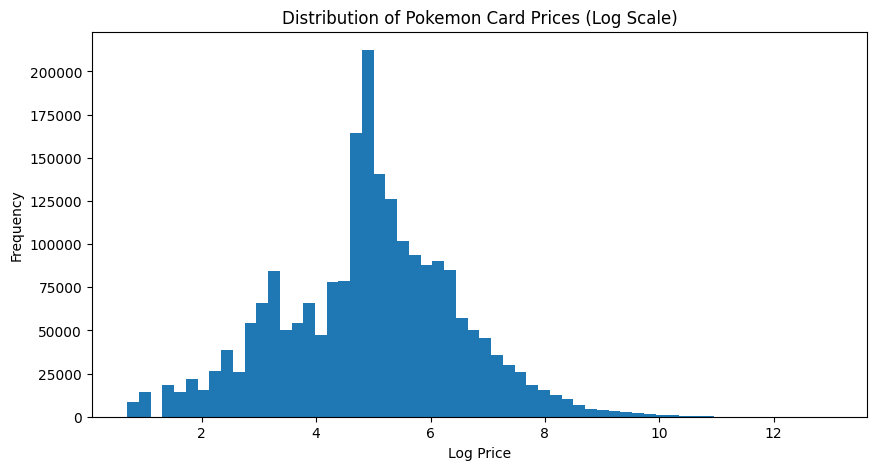

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 5))
plt.hist(clean_df['log_price'], bins = 60)
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.title('Distribution of Pokemon Card Prices (Log Scale)')
plt.show()

In [67]:
condition_split = clean_df['condition'].str.split('-', n=1, expand = True)
clean_df['print_type'] = condition_split[0]
clean_df['card_condition'] = condition_split[1]

print('Print types:')
print(clean_df['print_type'].value_counts())

print('\nCard conditions:')
print(clean_df['card_condition'].value_counts())

Print types:
print_type
normal     1093577
holo        697237
reverse     403555
Name: count, dtype: int64

Card conditions:
card_condition
good        1422492
nearmint     600135
played       102491
used          36494
poor          32757
Name: count, dtype: int64


In [68]:
clean_df['date'] = pd.to_datetime(clean_df['date'])

clean_df['year'] = clean_df['date'].dt.year
clean_df['month'] = clean_df['date'].dt.month

print(clean_df[['date', 'year', 'month']].head())

print('\nYears:')
print(clean_df['year'].value_counts().sort_index())

        date  year  month
0 2022-12-11  2022     12
1 2022-12-16  2022     12
2 2022-12-29  2022     12
3 2023-01-02  2023      1
4 2023-01-05  2023      1

Years:
year
2022     133283
2023     913806
2024    1147280
Name: count, dtype: int64


In [69]:
print('Number of rarities:', clean_df['rarity'].nunique())

print('\nRarity counts:')
print(clean_df['rarity'].value_counts().to_string())

Number of rarities: 28

Rarity counts:
rarity
Uncommon                     590766
Common                       512281
Rare                         286187
Rare Holo                    246324
Rare Ultra                   126084
Promo                         86464
Rare Holo V                   55502
Rare Rainbow                  44537
Rare Secret                   39463
Rare Holo EX                  35278
Rare Holo GX                  34465
Illustration Rare             25318
Rare Holo VMAX                24933
Ultra Rare                    19129
Special Illustration Rare     10574
Double Rare                    7539
Rare BREAK                     5950
Hyper Rare                     5443
Rare Prism Star                5357
Rare Holo VSTAR                3754
Amazing Rare                   3348
Rare Holo LV.X                 2706
Rare Prime                     2298
Rare Shining                   1824
Radiant Rare                   1434
LEGEND                         1296
Rare ACE          

In [70]:
rarity_stats = (
    clean_df.groupby('rarity')['avg_price'].agg(
        ['count', 'median', 'mean']
    ).sort_values('median', ascending = False))

print(rarity_stats)

                            count   median          mean
rarity                                                  
Rare Holo Star                241  25753.0  37882.543568
LEGEND                       1296   3587.0   4054.020833
Rare Shining                 1824   2395.0   8910.883772
Rare Holo LV.X               2706   1499.0   2239.553585
Special Illustration Rare   10574   1328.0   1993.655949
Rare Prime                   2298   1119.5   1728.989991
Rare Rainbow                44537    764.0   2426.981948
Rare ACE                     1050    734.5    957.784762
Rare Secret                 39463    700.0   1555.760611
Hyper Rare                   5443    572.0    721.154694
Rare Ultra                 126084    522.0   1551.124599
Illustration Rare           25318    520.0    780.014930
Rare Holo EX                35278    470.0   1200.450394
Rare Holo VSTAR              3754    327.0    438.721630
Ultra Rare                  19129    320.0    506.151759
Rare Holo GX                344

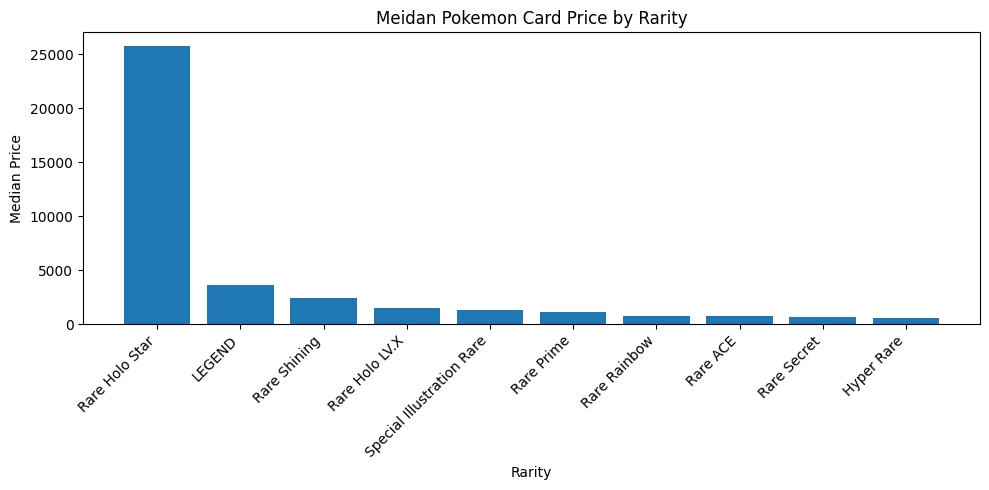

In [71]:
top_rarities = rarity_stats.head(10)

plt.figure(figsize = (10, 5))

plt.bar(
    top_rarities.index,
    top_rarities['median']
)

plt.xticks(rotation=45, ha = 'right')
plt.xlabel('Rarity')
plt.ylabel('Median Price')
plt.title('Meidan Pokemon Card Price by Rarity')

plt.tight_layout()
plt.show()

In [72]:
print('Total rows', len(clean_df))

print(
    'Unique cards:',
    clean_df[['set_id', 'card_number']].drop_duplicates().shape[0]
)

card_history_counts = (
    clean_df.groupby(['set_id', 'card_number']).size()
)

print('\nHistorical observations per card:')
print(card_history_counts.describe())

Total rows 2194369
Unique cards: 14689

Historical observations per card:
count    14689.000000
mean       149.388590
std        125.759144
min          1.000000
25%         59.000000
50%        104.000000
75%        207.000000
max        879.000000
dtype: float64


In [73]:
top_cards = (
    clean_df.groupby(['set_id', 'card_number', 'name'])
    .size().sort_values(ascending = False).head(20)
)

print(top_cards)

set_id  card_number  name               
swsh10  154          Switch Cart            879
swsh9   151          Double Turbo Energy    841
swsh10  146          Hisuian Heavy Ball     840
swsh9   132          Boss's Orders          804
base1   6            Gyarados               776
        7            Hitmonchan             775
base2   51           Eevee                  769
base3   10           Lapras                 766
swsh12  153          Capturing Aroma        765
base1   10           Mewtwo                 763
swsh9   121          Bibarel                760
base1   12           Ninetales              758
swsh10  155          Temple of Sinnoh       752
base2   60           Pikachu                749
base1   46           Charmander             749
base2   12           Vaporeon               747
        5            Kangaskhan             745
swsh10  147          Irida                  740
base1   44           Bulbasaur              737
swsh12  147          Archeops               735

## 4. Feature Engineering

In [74]:
clean_df = clean_df.sort_values(
    ['set_id', 'card_number', 'condition', 'date']
).copy()

clean_df['prev_price'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['avg_price']
    .shift(1)
)

print(
    clean_df[
        ['name', 'set_id', 'card_number',
         'condition', 'date', 'avg_price', 'prev_price']
    ].head(20)
)

            name set_id card_number  condition       date  avg_price  \
200858  Alakazam  base1           1  holo-good 2022-11-12       2298   
200859  Alakazam  base1           1  holo-good 2022-11-13       2844   
200860  Alakazam  base1           1  holo-good 2022-11-14       1895   
200861  Alakazam  base1           1  holo-good 2022-11-15       2308   
200862  Alakazam  base1           1  holo-good 2022-11-16       1493   
200863  Alakazam  base1           1  holo-good 2022-11-18       1563   
200864  Alakazam  base1           1  holo-good 2022-11-19       2024   
200865  Alakazam  base1           1  holo-good 2022-11-20       2607   
200866  Alakazam  base1           1  holo-good 2022-11-21       1171   
200867  Alakazam  base1           1  holo-good 2022-11-22        795   
200868  Alakazam  base1           1  holo-good 2022-11-23       1274   
200869  Alakazam  base1           1  holo-good 2022-11-24       1997   
200870  Alakazam  base1           1  holo-good 2022-11-25       

In [75]:
print('Rows with previous price:', clean_df['prev_price'].notna().sum())

print(
    'Coverage:',
    f'{clean_df['prev_price'].notna().mean() * 100:.2f}%'
)

Rows with previous price: 2111779
Coverage: 96.24%


In [76]:
clean_df['prev_date'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['date']
    .shift(1)
)

clean_df['days_since_prev'] = (
    clean_df['date'] - clean_df['prev_date']
).dt.days

print(
    clean_df[
        ['name', 'condition', 'date', 'avg_price', 'prev_price', 'prev_date', 'days_since_prev']
    ].head(20)
)

            name  condition       date  avg_price  prev_price  prev_date  \
200858  Alakazam  holo-good 2022-11-12       2298         NaN        NaT   
200859  Alakazam  holo-good 2022-11-13       2844      2298.0 2022-11-12   
200860  Alakazam  holo-good 2022-11-14       1895      2844.0 2022-11-13   
200861  Alakazam  holo-good 2022-11-15       2308      1895.0 2022-11-14   
200862  Alakazam  holo-good 2022-11-16       1493      2308.0 2022-11-15   
200863  Alakazam  holo-good 2022-11-18       1563      1493.0 2022-11-16   
200864  Alakazam  holo-good 2022-11-19       2024      1563.0 2022-11-18   
200865  Alakazam  holo-good 2022-11-20       2607      2024.0 2022-11-19   
200866  Alakazam  holo-good 2022-11-21       1171      2607.0 2022-11-20   
200867  Alakazam  holo-good 2022-11-22        795      1171.0 2022-11-21   
200868  Alakazam  holo-good 2022-11-23       1274       795.0 2022-11-22   
200869  Alakazam  holo-good 2022-11-24       1997      1274.0 2022-11-23   
200870  Alak

In [77]:
print(clean_df['days_since_prev'].describe())


print(
    'Coverage:',
    f'{clean_df['days_since_prev'].notna().mean() *100:.2f}%'
)

count    2.111779e+06
mean     8.537543e+00
std      2.327480e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      6.410000e+02
Name: days_since_prev, dtype: float64
Coverage: 96.24%


In [78]:
clean_df['price_change'] = (
    clean_df['avg_price'] - clean_df['prev_price']
)

clean_df['price_return'] = (
    clean_df['avg_price'] / clean_df['prev_price'] - 1
)

print(
    clean_df[
        ['name', 'condition', 'date', 'avg_price', 'prev_price','days_since_prev', 'price_change', 'price_return']
    ].head(20)
)

            name  condition       date  avg_price  prev_price  \
200858  Alakazam  holo-good 2022-11-12       2298         NaN   
200859  Alakazam  holo-good 2022-11-13       2844      2298.0   
200860  Alakazam  holo-good 2022-11-14       1895      2844.0   
200861  Alakazam  holo-good 2022-11-15       2308      1895.0   
200862  Alakazam  holo-good 2022-11-16       1493      2308.0   
200863  Alakazam  holo-good 2022-11-18       1563      1493.0   
200864  Alakazam  holo-good 2022-11-19       2024      1563.0   
200865  Alakazam  holo-good 2022-11-20       2607      2024.0   
200866  Alakazam  holo-good 2022-11-21       1171      2607.0   
200867  Alakazam  holo-good 2022-11-22        795      1171.0   
200868  Alakazam  holo-good 2022-11-23       1274       795.0   
200869  Alakazam  holo-good 2022-11-24       1997      1274.0   
200870  Alakazam  holo-good 2022-11-25       1127      1997.0   
200871  Alakazam  holo-good 2022-11-26       1399      1127.0   
200872  Alakazam  holo-go

In [79]:
print(clean_df['price_change'].describe())

print('\nPrice return:')
print(clean_df['price_return'].describe())

print(
    '\nCoverage:',
    f'{clean_df['price_return'].notna().mean() * 100:.2f}%'
)

count    2.111779e+06
mean     1.196868e+00
std      9.154616e+02
min     -1.748710e+05
25%     -7.300000e+01
50%      0.000000e+00
75%      7.400000e+01
max      1.601030e+05
Name: price_change, dtype: float64

Price return:
count    2.111779e+06
mean     1.843160e+00
std      1.360710e+01
min     -9.995059e-01
25%     -3.575419e-01
50%      0.000000e+00
75%      5.633803e-01
max      2.024000e+03
Name: price_return, dtype: float64

Coverage: 96.24%


In [80]:
extreme_returns = clean_df[
    (clean_df['price_return'] > 10)|
    (clean_df['price_return'] < -0.95)
].copy()

print('Extreme rows:', len(extreme_returns))
print(
    'Extreme percentage:',
    f'{len(extreme_returns) / clean_df['price_return'].notna().sum()*100:.2f}%'
)

extreme_returns[
    [
        'name',
        'set_id',
        'card_number',
        'condition',
        'date',
        'prev_price',
        'avg_price',
        'days_since_prev',
        'price_return'
    ]
].sort_values('price_return', ascending=False).head(30)

Extreme rows: 129358
Extreme percentage: 6.13%


,name,set_id,card_number,condition,date,prev_price,avg_price,days_since_prev,price_return
1910441,Galarian Chestplate,swsh6,141,normal-good,2024-08-04,1.0,2025,56.0,2024.0
1411070,Milotic,swsh7,38,reverse-good,2023-02-17,1.0,2024,11.0,2023.0
943626,Nacli,sv4,102,reverse-nearmint,2024-08-18,1.0,2015,1.0,2014.0
2164853,Oranguru,swsh12pt5,119,normal-nearmint,2024-07-30,1.0,2011,3.0,2010.0
1674527,Krookodile,sv1,117,normal-nearmint,2024-05-31,1.0,2009,2.0,2008.0
1944100,Barry,swsh9,130,normal-nearmint,2024-05-31,1.0,2009,1.0,2008.0
415826,Manaphy,swsh45,24,normal-good,2024-06-04,1.0,2009,2.0,2008.0
1791069,Chewtle,swsh8,80,normal-nearmint,2024-07-10,1.0,2009,1.0,2008.0
697005,Binacle,swsh11,106,normal-nearmint,2024-09-22,1.0,2004,4.0,2003.0
896716,Regenerative Energy,swsh12,168,normal-nearmint,2024-06-14,1.0,2004,1.0,2003.0


In [81]:
clean_df['log_return'] = (
    np.log(clean_df['avg_price']) -
    np.log(clean_df['prev_price'])
)

print(clean_df['log_return'].describe())

print('\nPercentiles:')
print(
    clean_df['log_return'].quantile(
        [0.001, 0.005, 0.01, 0.05, 0.50, 0.95, 0.99, 0.995, 0.999]
    )
)

count    2.111779e+06
mean     2.340488e-03
std      1.249683e+00
min     -7.612831e+00
25%     -4.424537e-01
50%      0.000000e+00
75%      4.468503e-01
max      7.613325e+00
Name: log_return, dtype: float64

Percentiles:
0.001   -5.115996
0.005   -4.143135
0.010   -3.646320
0.050   -2.140066
0.500    0.000000
0.950    2.147100
0.990    3.642836
0.995    4.132496
0.999    5.104733
Name: log_return, dtype: float64


In [82]:
lower = clean_df['log_return'].quantile(0.01)
upper = clean_df['log_return'].quantile(0.99)

clean_df['log_return_clipped'] = (
    clean_df['log_return'].clip(lower, upper)
)

print('Lower bound:', lower)
print('Upper bound:', upper)

print('\nOriginal log return:')
print(clean_df['log_return'].describe())

print('\nClipped log return:')
print(clean_df['log_return_clipped'].describe())

Lower bound: -3.64631983969514
Upper bound: 3.6428355156125294

Original log return:
count    2.111779e+06
mean     2.340488e-03
std      1.249683e+00
min     -7.612831e+00
25%     -4.424537e-01
50%      0.000000e+00
75%      4.468503e-01
max      7.613325e+00
Name: log_return, dtype: float64

Clipped log return:
count    2.111779e+06
mean     2.457403e-03
std      1.204253e+00
min     -3.646320e+00
25%     -4.424537e-01
50%      0.000000e+00
75%      4.468503e-01
max      3.642836e+00
Name: log_return_clipped, dtype: float64


In [83]:
clean_df['rolling_avg_5'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['avg_price']
    .transform(
        lambda x: x.shift(1).rolling(window = 5, min_periods = 1).mean()
    )
)

In [84]:
clean_df['rolling_std_5'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['log_return_clipped']
    .transform(
        lambda x: x.shift(1).rolling(window = 5, min_periods = 1).std()
    )
)

In [85]:
clean_df['momentum_5'] = (
    clean_df['prev_price'] / clean_df['rolling_avg_5'] - 1
)

In [86]:
features = [
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5'
]

print(clean_df[features].describe())

print('\nMissing values:')
print(clean_df[features].isnull().sum())

         prev_price  days_since_prev  rolling_avg_5  rolling_std_5  \
count  2.111779e+06     2.111779e+06   2.111779e+06   1.984263e+06   
mean   4.902203e+02     8.537543e+00   4.890901e+02   1.059172e+00   
std    1.891897e+03     2.327480e+01   1.805577e+03   7.910385e-01   
min    1.000000e+00     1.000000e+00   1.000000e+00   0.000000e+00   
25%    5.000000e+01     1.000000e+00   7.960000e+01   4.218657e-01   
50%    1.410000e+02     2.000000e+00   1.498000e+02   8.714137e-01   
75%    3.740000e+02     6.000000e+00   3.470000e+02   1.526302e+00   
max    4.500000e+05     6.410000e+02   4.500000e+05   5.154211e+00   

         momentum_5  
count  2.111779e+06  
mean   3.932132e-03  
std    6.801007e-01  
min   -9.980354e-01  
25%   -4.187426e-01  
50%   -5.550480e-02  
75%    2.042683e-01  
max    3.990065e+00  

Missing values:
prev_price          82590
days_since_prev     82590
rolling_avg_5       82590
rolling_std_5      210106
momentum_5          82590
dtype: int64


In [87]:
clean_df = clean_df.sort_values(
    ['set_id', 'card_number', 'condition', 'date']
).copy()

clean_df['target_price'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['avg_price']
    .shift(-1)
)

clean_df['target_date'] = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['date']
    .shift(-1)
)

clean_df['days_to_target'] = (
    clean_df['target_date'] - clean_df['date']
).dt.days

In [88]:
clean_df['target_log_price'] = np.log1p(
    clean_df['target_price']
)

In [89]:
print(
    clean_df[
        [
            'name',
            'date',
            'avg_price',
            'prev_price',
            'rolling_avg_5',
            'momentum_5',
            'target_date',
            'target_price',
            'days_to_target',
            'target_log_price',
        ]
    ].head(15)
)

print('\nTarget coverage:')
print(
    f"{clean_df['target_price'].notna().mean() * 100:.2f}%"
)

print('\nDays to target:')
print(clean_df['days_to_target'].describe())

            name       date  avg_price  prev_price  rolling_avg_5  momentum_5  \
200858  Alakazam 2022-11-12       2298         NaN            NaN         NaN   
200859  Alakazam 2022-11-13       2844      2298.0    2298.000000    0.000000   
200860  Alakazam 2022-11-14       1895      2844.0    2571.000000    0.106184   
200861  Alakazam 2022-11-15       2308      1895.0    2345.666667   -0.192127   
200862  Alakazam 2022-11-16       1493      2308.0    2336.250000   -0.012092   
200863  Alakazam 2022-11-18       1563      1493.0    2167.600000   -0.311220   
200864  Alakazam 2022-11-19       2024      1563.0    2020.600000   -0.226467   
200865  Alakazam 2022-11-20       2607      2024.0    1856.600000    0.090165   
200866  Alakazam 2022-11-21       1171      2607.0    1999.000000    0.304152   
200867  Alakazam 2022-11-22        795      1171.0    1771.600000   -0.339016   
200868  Alakazam 2022-11-23       1274       795.0    1632.000000   -0.512868   
200869  Alakazam 2022-11-24 

In [90]:
card_ranges = (
    clean_df.groupby(['set_id', 'card_number', 'condition'])['date'].agg(
        ['min', 'max', 'count']
    )
)

card_ranges['history_days'] = (
    card_ranges['max'] - card_ranges['min']
).dt.days

print(card_ranges['history_days'].describe())

print('\nGroups with at least 30 days of history:')
print(
    (card_ranges['history_days'] >= 30).sum(),
    '/',
    len(card_ranges)
)

print(
    f'{(card_ranges['history_days'] >= 30).mean() * 100:.2f}%'
)

count    82590.000000
mean       218.300097
std        251.931777
min          0.000000
25%         38.000000
50%        108.000000
75%        535.000000
max        682.000000
Name: history_days, dtype: float64

Groups with at least 30 days of history:
63471 / 82590
76.85%


In [91]:
target_lookup = clean_df[
    [
        'set_id', 'card_number',
        'condition', 'date', 'avg_price'
    ]
].copy()

target_lookup = target_lookup.rename(
    columns = {
        'date': 'target_date',
        'avg_price': 'target_price'
    }
)

clean_df['desired_target_date'] = (
    clean_df['date'] + pd.Timedelta(days = 30)
)

## 5. 30-Day Prediction Target

In [92]:
left_df = clean_df.sort_values('desired_target_date').copy()

right_df = target_lookup.sort_values('target_date').copy()

model_df = pd.merge_asof(
    left_df,
    right_df,
    left_on = 'desired_target_date',
    right_on = 'target_date',
    by = ['set_id', 'card_number', 'condition'],
    direction = 'forward'
)

In [93]:
model_df['actual_horizon_days'] = (
    model_df['target_date_y'] - model_df['date']
).dt.days

print('Total candidate rows:', len(model_df))

print(
    'Rows with 30day target:',
    model_df['target_price_y'].notna().sum()
)

print('Target coverage:',
f"{model_df['target_price_y'].notna().mean() * 100:.2f}%"
)

print('\nActual prediction horizon:')
print(model_df['actual_horizon_days'].describe())

Total candidate rows: 2194369
Rows with 30day target: 1854675
Target coverage: 84.52%

Actual prediction horizon:
count    1.854675e+06
mean     4.667828e+01
std      4.039396e+01
min      3.000000e+01
25%      3.000000e+01
50%      3.200000e+01
75%      4.000000e+01
max      6.410000e+02
Name: actual_horizon_days, dtype: float64


In [94]:
valid_target = (
    model_df['actual_horizon_days'].between(30, 45)
)

model_30d = model_df[valid_target].copy()

print('Original candidate rows:', len(model_df))
print('Valid 30-45 day targets:', len(model_30d))

print(
    'Final target coverage:',
    f'{len(model_30d) / len(model_df) * 100:.2f}%'
)
print('\nFinal prediction horizon:')
print(model_30d['actual_horizon_days'].describe())

Original candidate rows: 2194369
Valid 30-45 day targets: 1505311
Final target coverage: 68.60%

Final prediction horizon:
count    1.505311e+06
mean     3.276547e+01
std      3.742506e+00
min      3.000000e+01
25%      3.000000e+01
50%      3.100000e+01
75%      3.400000e+01
max      4.500000e+01
Name: actual_horizon_days, dtype: float64


In [95]:
model_30d['target_30d_price'] = model_30d['target_price_y']

model_30d['target_30d_log_price'] = np.log1p(
    model_30d['target_30d_price']
)

print(
    model_30d[
        ['date', 'avg_price', 'target_date_y', 'actual_horizon_days', 'target_30d_price', 'target_30d_log_price']
    ].head(10)
)

print('\nTarget price summary:')
print(model_30d['target_30d_price'].describe())

print('\nTarget log price summary:')
print(model_30d['target_30d_log_price'].describe())

        date  avg_price target_date_y  actual_horizon_days  target_30d_price  \
0 2022-11-12       2298    2022-12-12                 30.0             888.0   
1 2022-11-12        324    2022-12-14                 32.0               4.0   
2 2022-11-12         11    2022-12-15                 33.0              20.0   
3 2022-11-12        264    2022-12-16                 34.0             262.0   
4 2022-11-12        405    2022-12-12                 30.0             350.0   
5 2022-11-12       1049    2022-12-13                 31.0            1333.0   
6 2022-11-12        499    2022-12-12                 30.0             379.0   
7 2022-11-12        378    2022-12-12                 30.0             307.0   
8 2022-11-12         25    2022-12-18                 36.0             144.0   
9 2022-11-12        500    2022-12-12                 30.0             763.0   

   target_30d_log_price  
0              6.790097  
1              1.609438  
2              3.044522  
3              

In [96]:
print('Date range:')
print(model_30d['date'].min())
print(model_30d['date'].max())

print('\nRows by year:')
print(model_30d['date']
      .dt.year.value_counts().sort_index())

print('\nRows by month:')
print(
    model_30d['date'].dt.to_period('M').value_counts().sort_index()
)

Date range:
2022-11-12 00:00:00
2024-08-25 00:00:00

Rows by year:
date
2022     68120
2023    694893
2024    742298
Name: count, dtype: int64

Rows by month:
date
2022-11     14367
2022-12     53753
2023-01     44917
2023-02     50413
2023-03     96794
2023-04    116052
2023-05     96754
2023-06     44030
2023-07     43976
2023-08     38779
2023-09     70104
2023-10     93074
2024-05    115670
2024-06    226942
2024-07    230667
2024-08    169019
Freq: M, Name: count, dtype: int64


In [97]:
monthly_counts = (
    model_30d.set_index('date').resample('MS').size()
)

print(monthly_counts)

date
2022-11-01     14367
2022-12-01     53753
2023-01-01     44917
2023-02-01     50413
2023-03-01     96794
2023-04-01    116052
2023-05-01     96754
2023-06-01     44030
2023-07-01     43976
2023-08-01     38779
2023-09-01     70104
2023-10-01     93074
2023-11-01         0
2023-12-01         0
2024-01-01         0
2024-02-01         0
2024-03-01         0
2024-04-01         0
2024-05-01    115670
2024-06-01    226942
2024-07-01    230667
2024-08-01    169019
Freq: MS, dtype: int64


## 6. Train-Test Split and Baseline

In [98]:
train_df = model_30d[
    model_30d['date'] < '2023-11-01'
].copy()

test_df = model_30d[
    model_30d['date'] >= '2024-05-01'
].copy()

print('Train rows:', len(train_df))

print(
    'Train dates:',
    train_df['date'].min(),
    'to',
    train_df['date'].max()
)

print('\nTest rows:', len(test_df))
print(
    'Test dates:',
    test_df['date'].min(),
    'to',
    test_df['date'].max()
)

Train rows: 763013
Train dates: 2022-11-12 00:00:00 to 2023-10-28 00:00:00

Test rows: 742298
Test dates: 2024-05-15 00:00:00 to 2024-08-25 00:00:00


In [99]:
test_df['baseline_prediction'] = test_df['avg_price']

In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_true = test_df['target_30d_price']
y_pred = test_df['baseline_prediction']

baseline_mae = mean_absolute_error(y_true, y_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

baseline_log_mae = mean_absolute_error(
    np.log1p(y_true),
    np.log1p(y_pred)
)

print('=== Naive 30 Day Baseline ===')
print(f'MAE: {baseline_mae:.2f}')
print(f'RMSE: {baseline_rmse:.2f}')
print(f'Log MAE: {baseline_log_mae:.4f}')

=== Naive 30 Day Baseline ===
MAE: 172.13
RMSE: 689.33
Log MAE: 0.8277


In [101]:
feature_cols = [
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5',
    'rarity',
    'print_type',
    'card_condition'
]

target_col = 'target_30d_log_price'

train_model = train_df[
    feature_cols + [target_col]
].dropna().copy()

test_model = test_df[
    feature_cols + [target_col]
].dropna().copy()

print('Training rows:', len(train_model))
print('Test rows:', len(test_model))

print('\nFeatures:')
print(feature_cols)

Training rows: 725821
Test rows: 664201

Features:
['prev_price', 'days_since_prev', 'rolling_avg_5', 'rolling_std_5', 'momentum_5', 'rarity', 'print_type', 'card_condition']


## 7. Machine Learning Models

In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor

numeric_features = [
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5'
]

categorical_features = [
    'rarity',
    'print_type',
    'card_condition'
]

preprocessor = ColumnTransformer(
    transformers = [
        ('num', SimpleImputer(strategy = 'median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)
    ]
)

model_1 = HistGradientBoostingRegressor(
    learning_rate = 0.08,
    max_iter = 150,
    max_leaf_nodes= 31,
    random_state = 42
)

pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_1)
])

In [103]:
x_train = train_model[feature_cols]
y_train = train_model[target_col]

x_test = test_model[feature_cols]
y_test = test_model[target_col]

pipeline_1.fit(x_train, y_train)

print('Model 1 training complete.')

Model 1 training complete.


In [104]:
pred_log = pipeline_1.predict(x_test)

pred_price = np.expm1(pred_log)

actual_price = np.expm1(y_test)

baseline_pred = test_df.loc[test_model.index, 'avg_price'].values

model1_mae = mean_absolute_error(
    actual_price,
    pred_price
)

model1_rmse = np.sqrt(
    mean_squared_error(actual_price, pred_price)
)

model1_log_mae = mean_absolute_error(
    y_test,
    pred_log
)

baseline_mae_same = mean_absolute_error(
    actual_price, baseline_pred
)

baseline_rmse_same = np.sqrt(
    mean_squared_error(actual_price, baseline_pred)
)

baseline_log_mae_same = mean_absolute_error(
    y_test,
    np.log1p(baseline_pred)
)

In [107]:
print('=== Naive Baseline (Same Test Rows) ===')
print(f'MAE: {baseline_mae_same:.2f}')
print(f'RMSE: {baseline_rmse_same:.2f}')
print(f'Log MAE: {baseline_log_mae_same:.4f}')

print('\n=== Model 1 ===')
print(f'MAE: {model1_mae:.2f}')
print(f'RMSE: {model1_rmse:.2f}')
print(f'Log MAE: {model1_log_mae:.4f}')

print('\n=== Improvement vs Baseline ===')
print(
    f'MAE improvement: '
    f'{(baseline_mae_same - model1_mae) / baseline_mae_same * 100:.2f}%'
)

print(
    f'RMSE improvement: '
    f'{(baseline_rmse_same - model1_rmse) / baseline_rmse_same * 100:.2f}%'
)

print(
    f'Log MAE improvement: '
    f'{(baseline_log_mae_same - model1_log_mae) / baseline_log_mae_same * 100:.2f}%'
)

=== Naive Baseline (Same Test Rows) ===
MAE: 170.89
RMSE: 672.46
Log MAE: 0.8269

=== Model 1 ===
MAE: 150.37
RMSE: 939.91
Log MAE: 0.6916

=== Improvement vs Baseline ===
MAE improvement: 12.01%
RMSE improvement: -39.77%
Log MAE improvement: 16.36%


In [109]:
results_df = test_model.copy()

results_df['actual_price'] = actual_price
results_df['pred_price'] = pred_price
results_df['baseline_pred'] = baseline_pred

results_df['model_error'] = (
    results_df['pred_price'] - results_df['actual_price']
)

results_df['baseline_error'] = (
    results_df['baseline_pred'] - results_df['actual_price']
)

results_df['model_abs_error'] = results_df['model_error'].abs()

print('Largest Model 1 errors:')
print(
    results_df.sort_values('model_abs_error', ascending = False)
    [
        [
            'actual_price',
            'pred_price',
            'baseline_pred',
            'model_abs_error',
            'rarity',
            'print_type',
            'card_condition'
        ]
    ]
    .head(20)
)

Largest Model 1 errors:
         actual_price    pred_price  baseline_pred  model_abs_error  \
1635196      145000.0  17660.231451          81688    127339.768549   
1290470      130022.0  17660.231451          75199    112361.768549   
1750044      130099.0  17909.820981          50499    112189.179019   
1381617      101898.0  16717.442439          70468     85180.557561   
1471160       97499.0  15351.757935          19474     82147.242065   
1766239       94599.0  17861.742330          84666     76737.257670   
1759463       94599.0  18259.859490          81119     76339.140510   
1911614       92500.0  16712.454856          57799     75787.545144   
1895023       92259.0  17688.038788         145000     74570.961212   
1732323       91999.0  17698.733321          80077     74300.266679   
1536672       90804.0  17909.820981          82499     72894.179019   
1109609       89999.0  17651.755876          50098     72347.244124   
1218498       88998.0  18299.685088          90500   

In [110]:
train_model = train_model.copy()
test_model = test_model.copy()

train_model['current_price'] = np.expm1(
    train_model['log_price']
) if 'log_price' in train_model.columns else train_df.loc[
    train_model.index,
    'avg_price'
]

test_model['current_price'] = test_df.loc[
    test_model.index, 'avg_price'
]

train_model['current_log_price'] = np.log1p(
    train_model['current_price']
)

test_model['current_log_price'] = np.log1p(
    test_model['current_price']
)

print(
    train_model[
        ['current_price', 'current_log_price']
    ].describe()
)

print('\nTest:')
print(
    test_model[
        ['current_price', 'current_log_price']
    ].describe()
)

       current_price  current_log_price
count  725821.000000      725821.000000
mean      502.307266           4.942237
std      1780.954511           1.572477
min         1.000000           0.693147
25%        51.000000           3.951244
50%       136.000000           4.919981
75%       388.000000           5.963579
max    280099.000000          12.542902

Test:
       current_price  current_log_price
count  664201.000000      664201.000000
mean      465.692024           4.959442
std      1780.185185           1.529606
min         1.000000           0.693147
25%        63.000000           4.158883
50%       148.000000           5.003946
75%       372.000000           5.921578
max    145099.000000          11.885178


In [111]:
feature_cols_2 = [
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5',
    'current_log_price' ,
    'rarity',
    'print_type',
    'card_condition',
]

numeric_features_2 = [
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5',
    'current_log_price'
]

categorical_features_2 = [
    'rarity',
    'print_type',
    'card_condition'
]

x_train_2 = train_model[feature_cols_2]
x_test_2 = test_model[feature_cols_2]

y_train_2 = train_model['target_30d_log_price']
y_test_2 = test_model['target_30d_log_price']

In [112]:
preprocessor_2 = ColumnTransformer(
    transformers = [
        ('num', SimpleImputer(strategy = 'median'), numeric_features_2),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_2)
    ]
)

model_2 = HistGradientBoostingRegressor(
    learning_rate = 0.08,
    max_iter = 150,
    max_leaf_nodes= 31,
    random_state = 42
)

pipeline_2 = Pipeline([
    ('preprocessor', preprocessor_2),
    ('model', model_2)
])

pipeline_2.fit(x_train_2, y_train_2)

print('Model 2 training complete.')

Model 2 training complete.


In [113]:
pred_log_2 = pipeline_2.predict(x_test_2)

pred_price_2 = np.expm1(pred_log_2)

actual_price_2 = np.expm1(y_test_2)

baseline_pred_2 = test_model['current_price'].values

model2_mae = mean_absolute_error(
    actual_price_2,
    pred_price_2
)

model2_rmse = np.sqrt(
    mean_squared_error(actual_price_2, pred_price_2)
)

model2_log_mae = mean_absolute_error(
    y_test_2,
    pred_log_2
)

baseline2_mae = mean_absolute_error(
    actual_price_2,
    baseline_pred_2
)

baseline2_rmse = np.sqrt(
    mean_squared_error(actual_price_2, baseline_pred_2)
)

baseline2_log_mae = mean_absolute_error(
    y_test_2,
    np.log1p(baseline_pred_2)
)

In [114]:
print('=== Baseline ===')
print(f'MAE: {baseline2_mae:.2f}')
print(f'RMSE: {baseline2_rmse:.2f}')
print(f'Log MAE: {baseline2_log_mae:.4f}')

print('\n=== Model 2 ===')
print(f'MAE: {model2_mae:.2f}')
print(f'RMSE: {model2_rmse:.2f}')
print(f'Log MAE: {model2_log_mae:.4f}')

print('\n=== Improvement vs Baseline ===')
print(
    f'MAE improvement: '
    f'{(baseline2_mae - model2_mae) / baseline2_mae * 100:.2f}%'
)

print(
    f'RMSE improvement: '
    f'{(baseline2_rmse - model2_rmse)/baseline2_rmse*100:.2f}%'
)

print(
    f'Log MAE improvement: '
    f'{(baseline2_log_mae-model2_log_mae)/baseline2_log_mae*100:.2f}%'
)

=== Baseline ===
MAE: 170.89
RMSE: 672.46
Log MAE: 0.8269

=== Model 2 ===
MAE: 147.27
RMSE: 929.43
Log MAE: 0.6867

=== Improvement vs Baseline ===
MAE improvement: 13.82%
RMSE improvement: -38.21%
Log MAE improvement: 16.95%


In [115]:
evaluation_df = pd.DataFrame({
    'actual_price': actual_price_2,
    'model_pred' : pred_price_2,
    'baseline_pred': baseline_pred_2
})

evaluation_df['price_group'] = pd.cut(
    evaluation_df['actual_price'],
    bins = [0, 100, 500, 1000, 5000, 10000, 50000, np.inf],
    labels = [
        '$0-100',
        '$100-500',
        '$500-1k',
        '$1k-5k',
        '$5k-10k',
        '$10k-50k',
        '$50k+'
    ]
)

results_by_price = []

for group, df_group in evaluation_df.groupby(
    'price_group',
    observed = True
):

  model_mae = mean_absolute_error(
      df_group['actual_price'],
      df_group['model_pred']
  )

  baseline_mae = mean_absolute_error(
      df_group['actual_price'],
      df_group['baseline_pred']
  )

  improvement = (
      (baseline_mae - model_mae)
      / baseline_mae *100
  )

  results_by_price.append({
      'Price_group': group,
      'Rows': len(df_group),
      'Baseline MAE': baseline_mae,
      'Model 2 MAE': model_mae,
      'Improvement': improvement
  })

price_results_df = pd.DataFrame(results_by_price)

print(price_results_df.to_string(index = False))

Price_group   Rows  Baseline MAE  Model 2 MAE  Improvement
     $0-100 215118     84.822549    36.400881    57.085844
   $100-500 322254    105.620473    84.246559    20.236526
    $500-1k  70134    234.894545   210.229215    10.500597
     $1k-5k  50200    516.606892   428.156953    17.121324
    $5k-10k   3750   1856.653600  1670.092659    10.048236
   $10k-50k   2664   3917.137763  5689.784718   -45.253628
      $50k+     81  17508.024691 63962.934080  -265.334955


In [116]:
print(model_df.columns.tolist())

print('\nUnique sets:', model_df['set_id'].nunique())
print('Unique cards:', model_df[['set_id', 'card_number']].drop_duplicates().shape[0])

print('\nSet frequency:')
print(model_df['set_id'].value_counts().head(20))


['set_id', 'card_number', 'condition', 'date', 'avg_price', 'min_price', 'max_price', 'count', 'id', 'name', 'supertype', 'subtypes', 'hp', 'types', 'evolvesFrom', 'rules', 'attacks', 'weaknesses', 'retreatCost', 'convertedRetreatCost', 'artist', 'rarity', 'nationalPokedexNumbers', 'legalities', 'images', 'abilities', 'resistances', 'evolvesTo', 'regulationMark', 'level', 'flavorText', 'ancientTrait', 'log_price', 'print_type', 'card_condition', 'year', 'month', 'prev_price', 'prev_date', 'days_since_prev', 'price_change', 'price_return', 'log_return', 'log_return_clipped', 'rolling_avg_5', 'rolling_std_5', 'momentum_5', 'target_price_x', 'target_date_x', 'days_to_target', 'target_log_price', 'desired_target_date', 'target_date_y', 'target_price_y', 'actual_horizon_days']

Unique sets: 126
Unique cards: 14689

Set frequency:
set_id
swsh8     73770
swsh7     70092
base1     64601
swsh6     57109
swsh4     51361
swsh1     50846
swsh3     46231
gym1      44644
base5     44084
base4     43

In [117]:
model_df['current_log_price'] = np.log1p(model_df['avg_price'])

print('current_log_price created.')
print(
    model_df[['avg_price', 'current_log_price']].head()
)

current_log_price created.
   avg_price  current_log_price
0       2298           7.740230
1        324           5.783825
2         11           2.484907
3        264           5.579730
4        405           6.006353


In [118]:
feature_cols_3 = [
    'current_log_price',
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5',
    'rarity',
    'print_type',
    'card_condition',
    'set_id'
]

numeric_features_3 = [
    'current_log_price',
    'prev_price',
    'days_since_prev',
    'rolling_avg_5',
    'rolling_std_5',
    'momentum_5'
]

categorical_features_3 = [
    'rarity',
    'print_type',
    'card_condition',
    'set_id'
]

print('Missing columns:')
print([col for col in feature_cols_3 if col not in model_df.columns])

Missing columns:
[]


In [119]:
train_df['current_log_price'] = np.log1p(train_df['avg_price'])
test_df['current_log_price'] = np.log1p(test_df['avg_price'])

print('Train:', 'current_log_price' in train_df.columns)
print('Test:', 'current_log_price' in test_df.columns)

Train: True
Test: True


In [120]:
train_model_3 = train_df[
    [
        'current_log_price',
        'prev_price',
        'days_since_prev',
        'rolling_avg_5',
        'rolling_std_5',
        'momentum_5',
        'rarity',
        'print_type',
        'card_condition',
        'set_id',
        'target_30d_log_price'
    ]
].dropna().copy()

test_model_3 = test_df[
    [
        'current_log_price',
        'prev_price',
        'days_since_prev',
        'rolling_avg_5',
        'rolling_std_5',
        'momentum_5',
        'rarity',
        'print_type',
        'card_condition',
        'set_id',
        'target_30d_log_price'

    ]
].dropna().copy()

print('Train rows:', len(train_model_3))
print('Test rows:', len(test_model_3))

Train rows: 725821
Test rows: 664201


In [121]:
preprocessor_3 = ColumnTransformer(
    transformers = [
        ('num', SimpleImputer(strategy = 'median'), numeric_features_3),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_3)
    ]
)

model_3 = HistGradientBoostingRegressor(
    learning_rate = 0.08,
    max_iter = 150,
    max_leaf_nodes= 31,
    random_state = 42
)

pipeline_3 = Pipeline([
    ('preprocessor', preprocessor_3),
    ('model', model_3)
])

x_train_3 = train_model_3[feature_cols_3]
x_test_3 = test_model_3[feature_cols_3]

y_train_3 = train_model_3['target_30d_log_price']
y_test_3 = test_model_3['target_30d_log_price']

pipeline_3.fit(x_train_3, y_train_3)

print('Model 3 training complete.')

Model 3 training complete.


In [122]:
pred_log_3 = pipeline_3.predict(x_test_3)

pred_price_3 = np.expm1(pred_log_3)

actual_price_3 = np.expm1(y_test_3)

baseline_pred_3 = test_model_3['avg_price'].values if 'avg_price' in test_model_3.columns else np.expm1(
    test_model_3['current_log_price'].values
)

baseline_mae_3 = mean_absolute_error(actual_price_3, baseline_pred_3)
baseline_rmse_3 = np.sqrt(
    mean_squared_error(actual_price_3, baseline_pred_3)
)
baseline_log_mae_3 = mean_absolute_error(
    y_test_3,
    np.log1p(baseline_pred_3)
)

model3_mae = mean_absolute_error(actual_price_3, pred_price_3)
model3_rmse = np.sqrt(
    mean_squared_error(actual_price_3, pred_price_3)
)
model3_log_mae = mean_absolute_error(y_test_3, pred_log_3)

In [123]:
print('=== Baseline ===')
print(f'MAE: {baseline_mae_3:.2f}')
print(f'RMSE: {baseline_rmse_3:.2f}')
print(f'Log MAE: {baseline_log_mae_3:.4f}')

print('\n=== Model 3 ===')
print(f'MAE: {model3_mae:.2f}')
print(f'RMSE: {model3_rmse:.2f}')
print(f'Log MAE: {model3_log_mae:.4f}')

print('\n=== Improvement vs Baseline ===')
print(
    f'MAE improvement: '
    f'{(baseline_mae_3 - model3_mae) / baseline_mae_3 * 100:.2f}%'
)

print(
    f'RMSE improvement: '
    f'{(baseline_rmse_3 - model3_rmse)/baseline_rmse_3*100:.2f}%'
)

print(
    f'Log MAE improvement: '
    f'{(baseline_log_mae_3-model3_log_mae)/baseline_log_mae_3*100:.2f}%'
)

=== Baseline ===
MAE: 170.89
RMSE: 672.46
Log MAE: 0.8269

=== Model 3 ===
MAE: 147.29
RMSE: 931.59
Log MAE: 0.6877

=== Improvement vs Baseline ===
MAE improvement: 13.81%
RMSE improvement: -38.53%
Log MAE improvement: 16.84%


## 8. Model Evaluation and Interpretation

In [124]:
from sklearn.inspection import permutation_importance

sample_size = min(20000, len(x_test_2))

x_perm = x_test_2.sample(
    n = sample_size,
    random_state = 42
)

y_perm = y_test_2.loc[x_perm.index]

print('Permutation sample size:', len(x_perm))

perm_result = permutation_importance(
    pipeline_2,
    x_perm,
    y_perm,
    n_repeats = 5,
    random_state = 42,
    scoring = 'neg_mean_absolute_error',
    n_jobs = -1
)

importance_df = pd.DataFrame({
    'feature': x_perm.columns,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
}).sort_values(
    'importance',
    ascending = False
)

print(importance_df)

Permutation sample size: 20000
             feature  importance       std
2      rolling_avg_5    0.492505  0.002725
5  current_log_price    0.090551  0.001704
3      rolling_std_5    0.070366  0.001971
4         momentum_5    0.014787  0.000762
0         prev_price    0.004824  0.000685
1    days_since_prev    0.001574  0.000322
6             rarity    0.000762  0.000186
8     card_condition    0.000000  0.000000
7         print_type   -0.000270  0.000345


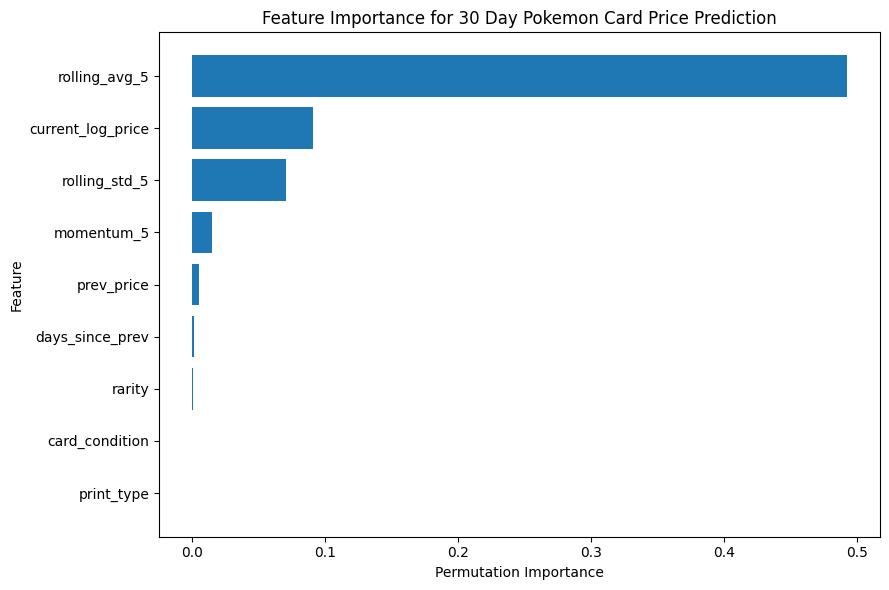

In [125]:
plot_df = importance_df.sort_values(
    'importance',
    ascending = True
)

plt.figure(figsize = (9, 6))
plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title(
    'Feature Importance for 30 Day Pokemon Card Price Prediction'
)

plt.tight_layout()
plt.show()

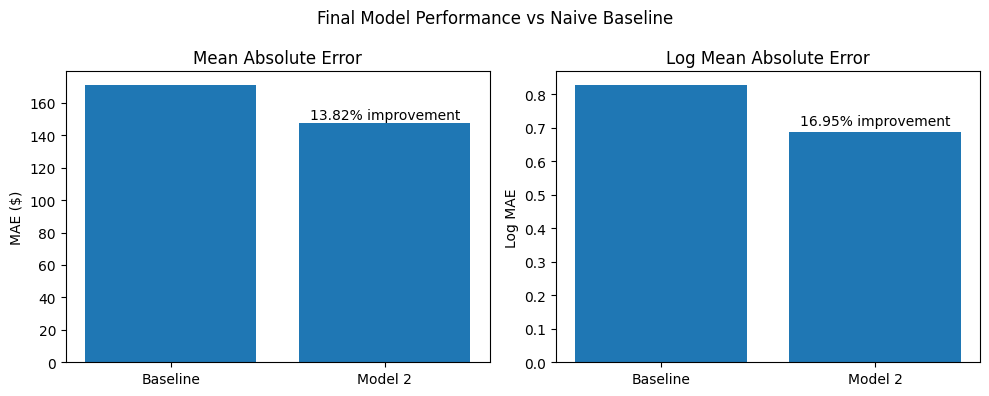

In [126]:
metrics_df = pd.DataFrame({
    'Matric': ['MAE', 'Log MAE'],
    'Baseline': [170.89, 0.8269],
    'Model 2': [147.27, 0.6867]
})

fig, axes = plt.subplots(1, 2, figsize = (10, 4))

axes[0].bar(
    ['Baseline', 'Model 2'],
    [170.89, 147.27]
)

axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('MAE ($)')

axes[0].text(
    1,
    147.27 + 3,
    '13.82% improvement',
    ha = 'center'
)

axes[1].bar(
    ['Baseline', 'Model 2'],
    [0.8269, 0.6867]
)

axes[1].set_title('Log Mean Absolute Error')
axes[1].set_ylabel('Log MAE')

axes[1].text(
    1,
    0.6867 + 0.02,
    '16.95% improvement',
    ha = 'center'
)

plt.suptitle(
    'Final Model Performance vs Naive Baseline'
)

plt.tight_layout()
plt.show()

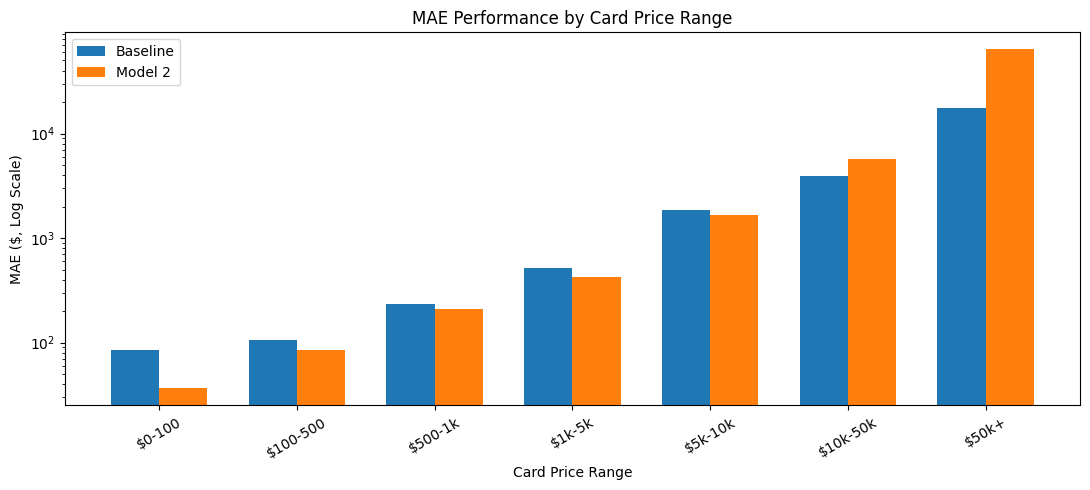

In [127]:
price_group_results = pd.DataFrame({
    'Price_group': [
        '$0-100',
        '$100-500',
        '$500-1k',
        '$1k-5k',
        '$5k-10k',
        '$10k-50k',
        '$50k+'
    ],
    'Baseline MAE': [
        84.82,
        105.62,
        234.89,
        516.61,
        1856.65,
        3917.14,
        17508.02
    ],
    'Model 2 MAE' : [
        36.40,
        84.25,
        210.23,
        428.16,
        1670.09,
        5689.78,
        63962.93
    ]
})

x = np.arange(len(price_group_results))
width = 0.35

plt.figure(figsize = (11, 5))

plt.bar(
    x-width/2,
    price_group_results['Baseline MAE'],
    width,
    label = 'Baseline'
)
plt.bar(
    x + width/2,
    price_group_results['Model 2 MAE'],
    width,
    label = 'Model 2'
)

plt.xticks(
    x,
    price_group_results['Price_group'],
    rotation = 30
)

plt.yscale('log')

plt.xlabel('Card Price Range')
plt.ylabel('MAE ($, Log Scale)')
plt.title('MAE Performance by Card Price Range')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Final Model Evaluation

Model 2 was selected as the final model for 30-day Pokémon card price prediction.

Compared with the naive baseline, Model 2 reduced overall MAE from \$170.89 to \$147.27, representing a 13.82% improvement. Log MAE improved from 0.8269 to 0.6867, a 16.95% improvement.

Performance varied substantially across price ranges. The model outperformed the baseline for cards priced below \$10,000, with the largest improvement occurring among cards below \$100. However, performance deteriorated for cards above $10,000, particularly for the small number of extremely high-value cards.

This explains why RMSE increased despite improvements in MAE and Log MAE: a small number of large prediction errors among expensive cards have a disproportionate effect on RMSE.

Permutation importance showed that the recent rolling average price was the strongest predictor, followed by current log price and recent price volatility. Static card characteristics such as rarity, print type, and condition contributed relatively little additional predictive power.

Overall, the results suggest that short-term Pokémon card prices are driven primarily by recent market behavior, while rare and extremely expensive cards remain substantially more difficult to predict.